<a href="https://colab.research.google.com/github/mbenedicto99/Python4DataScience/blob/master/BENE_PART1_Enunciado_Trabalho3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Trabalho 3. Detecção de Anomalias em ECG com Autoencoders: Identificação de Doenças Cardíacas

Nome 1:

Nome 2:

A base de dados **ECG5000**, proveniente do repositório público UCR/UEA, contém registros de sinais eletrocardiográficos (ECG) univariados com 140 pontos no tempo para cada amostra. Cada série está associada a uma classe, representando diferentes padrões de batimentos cardíacos, desde normais até anômalos. Por sua estrutura, essa base é amplamente utilizada em pesquisas de aprendizado de máquina aplicadas à saúde, permitindo explorar técnicas de classificação e detecção de anomalias em sinais biomédicos.

O objetivo deste trabalho é aplicar autoencoders para a detecção de doenças cardíacas a partir dos sinais de ECG da base **ECG5000**. O modelo deverá ser treinado para aprender a reconstruir padrões normais do sinal e, a partir do erro de reconstrução, identificar batimentos que apresentem comportamento anômalo, caracterizando possíveis condições patológicas.


## Conhecendo a base

A base de dados ECG5000 é composta por séries temporais de sinais eletrocardiográficos (ECG), cada uma com 140 pontos no tempo. Cada linha do arquivo corresponde a um batimento cardíaco registrado. O conjunto foi originalmente derivado de registros de pacientes com diferentes condições cardíacas e adaptado pelo repositório UCR/UEA Time Series Classification para tarefas de aprendizado de máquina.

Cada amostra possui um rótulo de classe na primeira coluna, seguido pelos valores do sinal nas demais colunas. As classes representam diferentes padrões de batimentos:

- Classe 1: batimentos normais (Normal).
- Classe 2: batimentos anormais do tipo R on T.
- Classe 3: batimentos anormais do tipo Premature Ventricular Contraction (PVC).
- Classe 4: batimentos anormais do tipo Supra-ventricular Premature ou Fusion.
- Classe 5: batimentos anormais do tipo Unclassifiable.

Apesar de a base trazer esses rótulos, em problemas de detecção de anomalias com autoencoders os modelos são treinados de forma não supervisionada, isto é, sem utilizar diretamente os rótulos. O objetivo é aprender o padrão dos batimentos normais (classe 1) e, a partir do erro de reconstrução, identificar batimentos que destoam desse padrão. Nesse contexto, os rótulos são usados apenas para avaliação final do desempenho do modelo.

Os dois arquivos (ECG5000_TRAIN.txt e ECG5000_TEST.txt) contêm amostras diferentes da base. Eles já vêm separados para seguir o protocolo experimental do repositório UCR/UEA, que padroniza divisões de treino e teste para permitir comparações justas entre diferentes métodos publicados. Assim, o arquivo TRAIN deve ser usado para treinar e ajustar o modelo, enquanto o arquivo TEST é reservado para a avaliação final, garantindo que o desempenho seja medido em dados nunca vistos durante o treinamento.

In [2]:
import pandas as pd

train = pd.read_csv("/content/ECG5000_TRAIN.txt", sep=r"\s+", header=None)

# Lendo o arquivo de teste (ECG5000_TEST.txt) com a mesma configuração
test = pd.read_csv("/content/ECG5000_TEST.txt", sep=r"\s+", header=None)

# Separa as colunas de sinais (todas menos a primeira) para X_train
X_train = train.iloc[:, 1:].values

# Separa a primeira coluna (rótulos/classes) para y_train
y_train = train.iloc[:, 0].values

# Faz o mesmo para o conjunto de teste: sinais
X_test = test.iloc[:, 1:].values

# Faz o mesmo para o conjunto de teste: rótulos
y_test = test.iloc[:, 0].values

## Parte 1. Análise Exploratória de Dados

Nesta primeira etapa do trabalho, o objetivo é realizar uma análise exploratória dos dados para compreender melhor a base ECG5000.

Para implementar esta análise, você deverá responder as perguntas abaixo. Além da resposta por extenso, você deve apresentar o código que usou para encontrar a resposta. Sempre que possível, adicione comentários nas linhas de código para ajudar o professor na correção

### 1.1. Quantas amostras existem no conjunto de treino e no conjunto de teste?

Resposta:

In [6]:
#Insira seu código aqui
import pandas as pd

train = pd.read_csv("/content/ECG5000_TRAIN.txt", sep=r"\s+", header=None)
test  = pd.read_csv("/content/ECG5000_TEST.txt", sep=r"\s+", header=None)

n_train = len(train)
n_test  = len(test)

print("Amostras no treino:", n_train)
print("Amostras no teste :", n_test)

# Checagem extra: número de pontos por série
timesteps_train = train.shape[1] - 1
timesteps_test  = test.shape[1] - 1
print("Pontos por série (train/test):", timesteps_train, timesteps_test)  # 140, 140

Amostras no treino: 500
Amostras no teste : 4500
Pontos por série (train/test): 140 140


### 1.2. Quantas amostras existem em cada classe (em treino, teste e total)?

Resposta:

In [7]:
#Insira seu código aqui
import pandas as pd
from collections import Counter

train = pd.read_csv("/content/ECG5000_TRAIN.txt", sep=r"\s+", header=None)
test  = pd.read_csv("/content/ECG5000_TEST.txt", sep=r"\s+", header=None)

y_train = train.iloc[:, 0].astype(int)
y_test  = test.iloc[:, 0].astype(int)

cnt_train = pd.Series(Counter(y_train)).sort_index()
cnt_test  = pd.Series(Counter(y_test)).sort_index()

all_classes = sorted(set(cnt_train.index).union(cnt_test.index))
df_counts = pd.DataFrame({
    "classe": all_classes,
    "treino": [cnt_train.get(c, 0) for c in all_classes],
    "teste":  [cnt_test.get(c, 0) for c in all_classes],
})
df_counts["total"] = df_counts["treino"] + df_counts["teste"]
print(df_counts)

   classe  treino  teste  total
0       1     292   2627   2919
1       2     177   1590   1767
2       3      10     86     96
3       4      19    175    194
4       5       2     22     24


### 1.3. Existem valores nulos na base?

Resposta:

In [8]:
#Insira seu código aqui
import pandas as pd
import numpy as np

train = pd.read_csv("/content/ECG5000_TRAIN.txt", sep=r"\s+", header=None)
test  = pd.read_csv("/content/ECG5000_TEST.txt", sep=r"\s+", header=None)

def check_nulls_and_infs(df):
    n_nan = int(df.isna().sum().sum())
    n_posinf = int(np.isposinf(df.select_dtypes(include=[np.number])).sum().sum())
    n_neginf = int(np.isneginf(df.select_dtypes(include=[np.number])).sum().sum())
    return n_nan, n_posinf, n_neginf

nan_tr, pinf_tr, ninf_tr = check_nulls_and_infs(train)
nan_te, pinf_te, ninf_te = check_nulls_and_infs(test)

print("Train  -> NaN:", nan_tr, " +Inf:", pinf_tr, " -Inf:", ninf_tr)
print("Test   -> NaN:", nan_te, " +Inf:", pinf_te, " -Inf:", ninf_te)

Train  -> NaN: 0  +Inf: 0  -Inf: 0
Test   -> NaN: 0  +Inf: 0  -Inf: 0


### 1.4. Plote alguns exemplos de sinais da classe normal (1). Plote exemplos de sinais das classes anômalas (2–5). Compare visualmente: quais diferenças você observa entre sinais normais e anômalos?

Resposta:

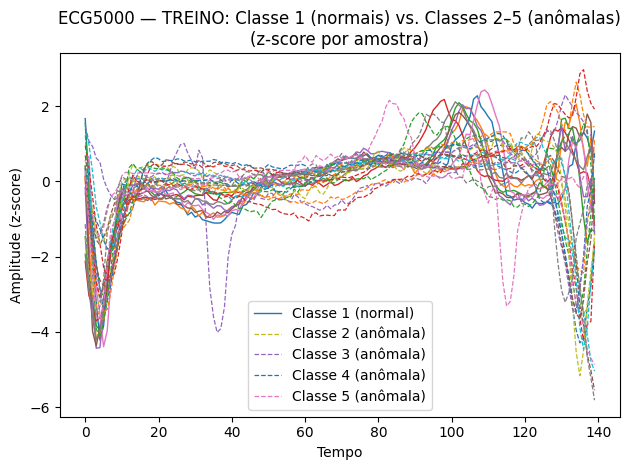

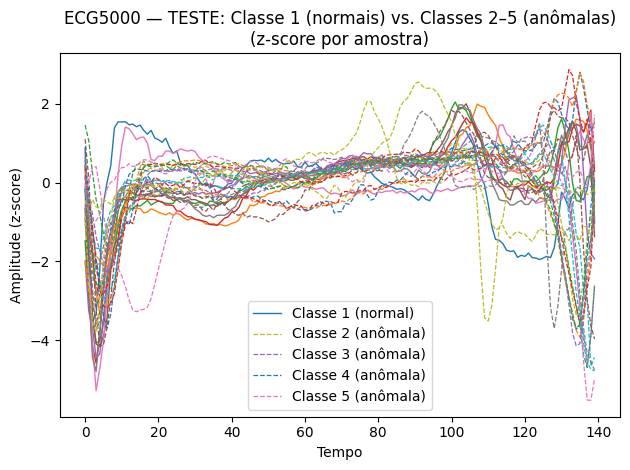

Figuras salvas em: /content/ecg_plots


In [12]:
#Insira seu código aqui
# -*- coding: utf-8 -*-

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# -------------------------------------------------------------------
# 1) Leitura dos dados (formato UCR: 1ª coluna = rótulo, demais = série)
# -------------------------------------------------------------------
train = pd.read_csv("/content/ECG5000_TRAIN.txt", sep=r"\s+", header=None)
test  = pd.read_csv("/content/ECG5000_TEST.txt",  sep=r"\s+", header=None)

y_tr = train.iloc[:, 0].astype(int).values
X_tr = train.iloc[:, 1:].astype(np.float32).values

y_te = test.iloc[:, 0].astype(int).values
X_te = test.iloc[:, 1:].astype(np.float32).values

# -------------------------------------------------------------------
# 2) Normalização por amostra (foco na morfologia, não na escala)
# -------------------------------------------------------------------
def zscore_per_sample(X, eps=1e-8):
    mu = X.mean(axis=1, keepdims=True)
    sd = X.std(axis=1, keepdims=True) + eps
    return (X - mu) / sd

X_tr_z = zscore_per_sample(X_tr)
X_te_z = zscore_per_sample(X_te)

# -------------------------------------------------------------------
# 3) Utilitários de amostragem e plot
# -------------------------------------------------------------------
rng = np.random.default_rng(42)  # reprodutível

def pick_indices(y, clazz, n):
    """Seleciona até n índices da classe 'clazz' (sem reposição)."""
    idx = np.where(y == clazz)[0]
    if len(idx) == 0:
        return np.array([], dtype=int)
    if len(idx) <= n:
        return idx
    return rng.choice(idx, size=n, replace=False)

def plot_set(Xz, y, title, out_path,
             n_norm=8, n_c2=6, n_c3=6, n_c4=6, n_c5=3):
    """Plota um conjunto (Xz,y) com normais vs anômalas e salva em out_path."""
    # Seleção de exemplos por classe
    idx_norm = pick_indices(y, 1, n_norm)
    idx_c2   = pick_indices(y, 2, n_c2)
    idx_c3   = pick_indices(y, 3, n_c3)
    idx_c4   = pick_indices(y, 4, n_c4)
    idx_c5   = pick_indices(y, 5, n_c5)

    plt.figure()
    # Normais (linha contínua)
    for k, i in enumerate(idx_norm):
        plt.plot(Xz[i], linewidth=1.0,
                 label="Classe 1 (normal)" if k == 0 else None)

    # Anômalas (linhas tracejadas)
    for idxs, label in [
        (idx_c2, "Classe 2 (anômala)"),
        (idx_c3, "Classe 3 (anômala)"),
        (idx_c4, "Classe 4 (anômala)"),
        (idx_c5, "Classe 5 (anômala)")
    ]:
        for j, i in enumerate(idxs):
            plt.plot(Xz[i], linewidth=0.9, linestyle="--",
                     label=label if j == 0 else None)

    plt.title(title + "\n(z-score por amostra)")
    plt.xlabel("Tempo")
    plt.ylabel("Amplitude (z-score)")
    plt.legend(loc="best")
    plt.tight_layout()
    plt.savefig(out_path, dpi=120)
    plt.show()

# -------------------------------------------------------------------
# 4) Saída e execução
# -------------------------------------------------------------------
outdir = Path("/content/ecg_plots")
outdir.mkdir(parents=True, exist_ok=True)

plot_set(
    X_tr_z, y_tr,
    title="ECG5000 — TREINO: Classe 1 (normais) vs. Classes 2–5 (anômalas)",
    out_path=outdir / "comparativo_train.png"
)

plot_set(
    X_te_z, y_te,
    title="ECG5000 — TESTE: Classe 1 (normais) vs. Classes 2–5 (anômalas)",
    out_path=outdir / "comparativo_test.png"
)

print("Figuras salvas em:", outdir)

### 1.5. Calcule estatísticas descritivas básicas para os sinais de cada classe (1 a 5) da base ECG5000. Para cada classe, determine e apresente: valor mínimo, valor máximo, média, mediana, desvio padrão. Em seguida, compare os resultados obtidos entre as classes. Existem diferenças significativas?

Resposta:

In [14]:
#Insira seu código aqui
# -*- coding: utf-8 -*-

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# -----------------------------
# 1) Ler dados (treino + teste)
# -----------------------------
train = pd.read_csv("/content/ECG5000_TRAIN.txt", sep=r"\s+", header=None)
test  = pd.read_csv("/content/ECG5000_TEST.txt",  sep=r"\s+", header=None)

# Concatena para calcular estatísticas no conjunto total disponível
df = pd.concat([train, test], ignore_index=True)

# Coluna 0 = classe; colunas 1.. = pontos no tempo
y = df.iloc[:, 0].astype(int).values
X = df.iloc[:, 1:].astype(np.float64).values  # float64 p/ precisão nas estatísticas

# --------------------------------------------
# 2) Estatísticas por classe (min, max, etc.)
# --------------------------------------------
rows = []
classes = sorted(np.unique(y))
for c in classes:
    Xc = X[y == c]          # (n_amostras_da_classe, T)
    flat = Xc.ravel()       # todos os pontos (amostras x tempo) dessa classe
    rows.append({
        "classe": int(c),
        "n_amostras": int(Xc.shape[0]),
        "min": float(np.min(flat)),
        "max": float(np.max(flat)),
        "media": float(np.mean(flat)),
        "mediana": float(np.median(flat)),
        "desvio_padrao": float(np.std(flat, ddof=0)),  # população
    })

desc_df = pd.DataFrame(rows).sort_values("classe").reset_index(drop=True)

# --------------------------------------------
# 3) Salvar CSV e preparar diretório de saída
# --------------------------------------------
outdir = Path("/content/ecg_stats_plots")
outdir.mkdir(parents=True, exist_ok=True)
csv_path = outdir / "estatisticas_descritivas_por_classe.csv"
desc_df.to_csv(csv_path, index=False)

print("Resumo por classe:")
print(desc_df.to_string(index=False))
print(f"\nCSV salvo em: {csv_path}")

# -------------------------------------------------------------
# 4) Gráfico 1 — Média ± DP (barras + barras de erro) + Mediana
# -------------------------------------------------------------
plt.figure()
x = np.arange(len(classes))
means = desc_df["media"].values
stds  = desc_df["desvio_padrao"].values
meds  = desc_df["mediana"].values

plt.bar(x, means)                                 # barras da média
plt.errorbar(x, means, yerr=stds, fmt='none', capsize=4)  # barras de erro = DP
plt.plot(x, meds, linestyle='', marker='o')       # marcadores da mediana

plt.xticks(x, desc_df["classe"].astype(str).tolist())
plt.xlabel("Classe")
plt.ylabel("Valor (amplitude)")
plt.title("ECG5000 — Média ± DP e Mediana por Classe")
plt.tight_layout()
plot1_path = outdir / "stats_media_dp_mediana_por_classe.png"
plt.savefig(plot1_path, dpi=120)
plt.close()

# ------------------------------------------------
# 5) Gráfico 2 — Mínimos e Máximos lado a lado
# ------------------------------------------------
plt.figure()
width = 0.35
mins = desc_df["min"].values
maxs = desc_df["max"].values

plt.bar(x - width/2, mins, width, label="Mínimo")
plt.bar(x + width/2, maxs, width, label="Máximo")

plt.xticks(x, desc_df["classe"].astype(str).tolist())
plt.xlabel("Classe")
plt.ylabel("Valor (amplitude)")
plt.title("ECG5000 — Mínimos e Máximos por Classe")
plt.legend()
plt.tight_layout()
plot2_path = outdir / "stats_min_max_por_classe.png"
plt.savefig(plot2_path, dpi=120)
plt.close()

Resumo por classe:
 classe  n_amostras       min      max         media  mediana  desvio_padrao
      1        2919 -7.090374 4.966414 -5.504065e-12 0.075356       0.996422
      2        1767 -5.880890 7.402103 -1.350425e-12 0.293244       0.996422
      3          96 -6.092227 3.075939 -4.512187e-11 0.199915       0.996422
      4         194 -5.639460 2.974619  5.043844e-11 0.180876       0.996422
      5          24 -4.754057 2.433236  7.766072e-11 0.162044       0.996422

CSV salvo em: /content/ecg_stats_plots/estatisticas_descritivas_por_classe.csv


### 1.6. Quantos atributos (features) cada amostra possui? O que eles significam?

Resposta:

In [15]:
import pandas as pd

# Formato UCR: col 0 = classe; col 1..T = série temporal (features)
train = pd.read_csv("/content/ECG5000_TRAIN.txt", sep=r"\s+", header=None)
test  = pd.read_csv("/content/ECG5000_TEST.txt",  sep=r"\s+", header=None)

T_train = train.shape[1] - 1
T_test  = test.shape[1] - 1

print(f"Features por amostra (train): {T_train}")
print(f"Features por amostra (test) : {T_test}")

Features por amostra (train): 140
Features por amostra (test) : 140


### 1.7. Por que faz sentido usar apenas sinais da classe 1 (normal) no treinamento do autoencoder? Como os rótulos podem ser utilizados posteriormente, mesmo que o treinamento seja não supervisionado? O que você espera que aconteça com o erro de reconstrução em batimentos normais vs. anômalos?

Resposta: Porque o autoencoder aprende o “padrão” do batimento saudável. Como não vê doença no treino, tende a reconstruir pior formas que fujam desse padrão (anomalias). É a ideia de "novelty detection". Depois de treinar, calculo o erro de reconstrução por batimento e uso os rótulos apenas para: (1) avaliar métricas (AUROC/AUPRC, sensibilidade, especificidade), (2) calibrar o limiar do erro que separa normal vs. anômalo e (3) analisar FP/FN. Baixo nos normais (classe 1) e alto nas anomalias (classes 2–5). Se houver boa separação, a curva ROC/PR melhora. Observação: precisa de AE undercomplete/regularizado e dados limpos, senão ele pode “copiar” tudo e perder o contraste.

## 2. Pré-processamento

Nesta segunda etapa do trabalho, o objetivo é realizar o pré-processamento da base de dados, garantindo que ela esteja adequada para a aplicação dos autoencoders.

### 2.1. Considerando as features que fazem parte da base, é necessário padronizar os dados antes de treinar a rede neural? Por que? Se sim, realize a padronização

Resposta: Sim. Padronizar ajuda o AE a focar na forma do ECG e evita que offsets ou amplitude dominem a perda. Como “features” são pontos no tempo do mesmo traçado, a melhor prática aqui é z-score por amostra (linha a linha): subtrai a média e divide pelo desvio-padrão da própria série, preservando morfologia.

In [16]:
#Insira seu código aqui
# -*- coding: utf-8 -*-

import numpy as np
import pandas as pd
from pathlib import Path

TRAIN_PATH = "/content/ECG5000_TRAIN.txt"
TEST_PATH  = "/content/ECG5000_TEST.txt"
OUTDIR = Path("/content/ecg_preproc_ae")
VAL_RATIO = 0.2
SEED = 42

OUTDIR.mkdir(parents=True, exist_ok=True)
rng = np.random.default_rng(SEED)

# 1) Leitura
train = pd.read_csv(TRAIN_PATH, sep=r"\s+", header=None)
test  = pd.read_csv(TEST_PATH,  sep=r"\s+", header=None)

y_tr = train.iloc[:, 0].astype(int).values
X_tr = train.iloc[:, 1:].astype(np.float32).values
y_te = test.iloc[:, 0].astype(int).values
X_te = test.iloc[:, 1:].astype(np.float32).values

assert X_tr.shape[1] == X_te.shape[1] == 140, "Esperado 140 pontos por amostra."
assert np.isfinite(X_tr).all() and np.isfinite(X_te).all(), "NaN/Inf detectados."

# 2) Z-score por amostra (média 0, desvio 1 por série)
def zscore_per_sample(X, eps=1e-8):
    mu = X.mean(axis=1, keepdims=True)
    sd = X.std(axis=1, keepdims=True) + eps
    return (X - mu) / sd

X_tr_z = zscore_per_sample(X_tr)
X_te_z = zscore_per_sample(X_te)

# 3) Seleciona classe 1 para o AE e faz split treino/val
is_normal = (y_tr == 1)
X_norm = X_tr_z[is_normal]
n = len(X_norm)
idx = np.arange(n); rng.shuffle(idx)
n_val = int(np.round(VAL_RATIO * n))
val_idx, tr_idx = idx[:n_val], idx[n_val:]

X_ae_train = X_norm[tr_idx]
X_ae_val   = X_norm[val_idx]
y_ae_train = np.ones(len(X_ae_train), dtype=np.int32)
y_ae_val   = np.ones(len(X_ae_val),   dtype=np.int32)

# 4) Persistência
np.save(OUTDIR / "X_ae_train.npy", X_ae_train.astype(np.float32))
np.save(OUTDIR / "y_ae_train.npy",  y_ae_train)
np.save(OUTDIR / "X_ae_val.npy",   X_ae_val.astype(np.float32))
np.save(OUTDIR / "y_ae_val.npy",    y_ae_val)
np.save(OUTDIR / "X_test.npy",     X_te_z.astype(np.float32))
np.save(OUTDIR / "y_test.npy",      y_te.astype(np.int32))

# (opcional) salvar todo o treino z-score e rótulos
np.save(OUTDIR / "X_train_z_all.npy", X_tr_z.astype(np.float32))
np.save(OUTDIR / "y_train_all.npy",   y_tr.astype(np.int32))

print("Padronização concluída.")
print({
    "X_ae_train": X_ae_train.shape,
    "X_ae_val":   X_ae_val.shape,
    "X_test":     X_te_z.shape
})

Padronização concluída.
{'X_ae_train': (234, 140), 'X_ae_val': (58, 140), 'X_test': (4500, 140)}


### 2.2. É necessário realizar remoção de outliers? Por que? Se sim, remova-os

Resposta: Não é “obrigatório”, mas recomendável remover artefatos/outliers dentro da classe 1 (normal) antes de treinar o AE. Em novelty detection, se o conjunto de normais estiver “contaminado” (sinais com spikes, saturação, batimentos atípicos ou quase constantes), o autoencoder aprende um manifold “sujo” e perde contraste na anomalia.

In [17]:
#Insira seu código aqui
# -*- coding: utf-8 -*-

import numpy as np
import pandas as pd
from pathlib import Path

TRAIN_PATH = "/content/ECG5000_TRAIN.txt"
TEST_PATH  = "/content/ECG5000_TEST.txt"
OUTDIR     = Path("/content/ecg_preproc_ae_clean")
SEED = 42

OUTDIR.mkdir(parents=True, exist_ok=True)
rng = np.random.default_rng(SEED)

# -----------------------------
# 1) Leitura (formato UCR)
# -----------------------------
train = pd.read_csv(TRAIN_PATH, sep=r"\s+", header=None)
test  = pd.read_csv(TEST_PATH,  sep=r"\s+", header=None)

y_tr = train.iloc[:, 0].astype(int).values
X_tr = train.iloc[:, 1:].astype(np.float32).values
y_te = test.iloc[:, 0].astype(int).values
X_te = test.iloc[:, 1:].astype(np.float32).values

assert X_tr.shape[1] == X_te.shape[1] == 140

# -----------------------------
# 2) Filtros de outliers (classe 1)
# -----------------------------
is_normal = (y_tr == 1)
X_norm = X_tr[is_normal]

# (A) std pré-zscore muito baixo (quase constante)
std_pre = X_norm.std(axis=1)
mask_A = std_pre > 1e-6   # mantém quem tem variação mínima

# z-score por amostra
def zscore_per_sample(X, eps=1e-8):
    mu = X.mean(axis=1, keepdims=True)
    sd = X.std(axis=1, keepdims=True) + eps
    return (X - mu) / sd

X_norm_z = zscore_per_sample(X_norm)

# (B) spikes/saturação: algum ponto com |z| > 6
absmax_z = np.max(np.abs(X_norm_z), axis=1)
mask_B = absmax_z <= 6.0

# (C) energia do derivado (medida simples de variação):
#     E = sum((diff(x))^2); outliers por Q3 + 3*IQR
diff = np.diff(X_norm_z, axis=1)
energy = np.sum(diff**2, axis=1)
q1, q3 = np.percentile(energy, [25, 75])
iqr = q3 - q1
upper_whisker = q3 + 3.0*iqr   # regra conservadora
mask_C = energy <= upper_whisker

# Combinação dos filtros
keep = mask_A & mask_B & mask_C
removed = (~keep).sum()

print(f"Normais no treino (classe 1): {len(X_norm)}")
print(f"Removidos por filtros (união): {removed} ({removed/len(X_norm):.1%})")

# Dados finais para o AE (limpos + z-score por amostra)
X_ae_all = X_norm_z[keep]
y_ae_all = np.ones(len(X_ae_all), dtype=np.int32)

# Split treino/val reprodutível (80/20)
idx = np.arange(len(X_ae_all))
rng.shuffle(idx)
n_val = int(0.2 * len(idx))
val_idx, tr_idx = idx[:n_val], idx[n_val:]

X_ae_train = X_ae_all[tr_idx]
X_ae_val   = X_ae_all[val_idx]
y_ae_train = np.ones(len(X_ae_train), dtype=np.int32)
y_ae_val   = np.ones(len(X_ae_val),   dtype=np.int32)

# Teste: apenas z-score por amostra (sem remoção — usamos rótulos pra avaliar)
X_te_z = zscore_per_sample(X_te)
y_test = y_te.astype(np.int32)

# -----------------------------
# 3) Salvar saídas
# -----------------------------
np.save(OUTDIR / "X_ae_train.npy", X_ae_train.astype(np.float32))
np.save(OUTDIR / "y_ae_train.npy",  y_ae_train)
np.save(OUTDIR / "X_ae_val.npy",   X_ae_val.astype(np.float32))
np.save(OUTDIR / "y_ae_val.npy",    y_ae_val)
np.save(OUTDIR / "X_test.npy",     X_te_z.astype(np.float32))
np.save(OUTDIR / "y_test.npy",      y_test)

# (opcional) logs dos filtros para relatório
np.save(OUTDIR / "qc_mask_keep.npy", keep)
np.save(OUTDIR / "qc_energy.npy",    energy)
np.save(OUTDIR / "qc_absmax_z.npy",  absmax_z)
np.save(OUTDIR / "qc_std_pre.npy",   std_pre)

print("Arquivos gerados em:", str(OUTDIR))

Normais no treino (classe 1): 292
Removidos por filtros (união): 1 (0.3%)
Arquivos gerados em: /content/ecg_preproc_ae_clean


### 2.3. É necessário realizar o balanceamento do dataset? Se sim, realize-o

Resposta: Para treinar o autoencoder (AE) não é necessário “balancear” classes — o AE será treinado apenas com a classe 1 (normal) (one-class / novelty detection).
Já para avaliar e calibrar o limiar, o conjunto costuma ser desbalanceado (muito mais normais). Isso pode distorcer métricas e a escolha do limiar. Então, além do conjunto “natural” (desbalanceado), é útil montar um conjunto de avaliação balanceado (apenas para análise/calibração), por exemplo, subamostrando normais para igualar o número de anomalias.

In [18]:
#Insira seu código aqui
# -*- coding: utf-8 -*-

import numpy as np
import pandas as pd
from pathlib import Path

TRAIN_PATH = "/content/ECG5000_TRAIN.txt"
TEST_PATH  = "/content/ECG5000_TEST.txt"
OUTDIR     = Path("/content/ecg_balancing")
VAL_RATIO  = 0.2
SEED       = 42

OUTDIR.mkdir(parents=True, exist_ok=True)
rng = np.random.default_rng(SEED)

# -------- 1) Leitura ----------
train = pd.read_csv(TRAIN_PATH, sep=r"\s+", header=None)
test  = pd.read_csv(TEST_PATH,  sep=r"\s+", header=None)

y_tr = train.iloc[:, 0].astype(int).values
X_tr = train.iloc[:, 1:].astype(np.float32).values
y_te = test.iloc[:, 0].astype(int).values
X_te = test.iloc[:, 1:].astype(np.float32).values

assert X_tr.shape[1] == X_te.shape[1] == 140, "Esperado 140 pontos por amostra."

# -------- 2) Z-score por amostra ----------
def zscore_per_sample(X, eps=1e-8):
    mu = X.mean(axis=1, keepdims=True)
    sd = X.std(axis=1, keepdims=True) + eps
    return (X - mu) / sd

X_tr_z = zscore_per_sample(X_tr)
X_te_z = zscore_per_sample(X_te)

# -------- 3) AE: treino/val só com classe 1 ----------
is_normal_tr = (y_tr == 1)
X_norm = X_tr_z[is_normal_tr]
n = len(X_norm)
idx = np.arange(n); rng.shuffle(idx)
n_val = int(np.round(VAL_RATIO * n))
val_idx, tr_idx = idx[:n_val], idx[n_val:]

X_ae_train = X_norm[tr_idx]
X_ae_val   = X_norm[val_idx]
y_ae_train = np.ones(len(X_ae_train), dtype=np.int32)
y_ae_val   = np.ones(len(X_ae_val),   dtype=np.int32)

# -------- 4) Avaliação: natural vs balanceado ----------
# Natural = teste completo (desbalanceado)
X_eval_natural = X_te_z.copy()
y_eval_natural = y_te.astype(np.int32)

# Balanceado = undersampling de normais para igualar nº de anomalias
is_normal_te = (y_te == 1)
is_anom_te   = ~is_normal_te
n_anom = int(is_anom_te.sum())

if n_anom > 0 and is_normal_te.sum() > 0:
    norm_idx = np.where(is_normal_te)[0]
    anom_idx = np.where(is_anom_te)[0]
    # escolher min(n_normais, n_anomalias); aqui igualamos aos anômalos
    take_norm = min(len(norm_idx), n_anom)
    sel_norm_idx = rng.choice(norm_idx, size=take_norm, replace=False)
    sel_idx = np.concatenate([sel_norm_idx, anom_idx])
    rng.shuffle(sel_idx)

    X_eval_bal = X_te_z[sel_idx]
    y_eval_bal = y_te[sel_idx].astype(np.int32)
else:
    # se o teste não tiver anomalias, não há como balancear
    X_eval_bal = X_eval_natural.copy()
    y_eval_bal = y_eval_natural.copy()

# -------- 5) Salvar saídas ----------
np.save(OUTDIR / "X_ae_train.npy", X_ae_train.astype(np.float32))
np.save(OUTDIR / "y_ae_train.npy",  y_ae_train)
np.save(OUTDIR / "X_ae_val.npy",   X_ae_val.astype(np.float32))
np.save(OUTDIR / "y_ae_val.npy",    y_ae_val)

np.save(OUTDIR / "X_eval_natural.npy", X_eval_natural.astype(np.float32))
np.save(OUTDIR / "y_eval_natural.npy", y_eval_natural)

np.save(OUTDIR / "X_eval_balanced.npy", X_eval_bal.astype(np.float32))
np.save(OUTDIR / "y_eval_balanced.npy", y_eval_bal)

# -------- 6) Resumo ----------
def counts(arr):
    u, c = np.unique(arr, return_counts=True)
    return dict(zip(u.tolist(), c.tolist()))

summary = {
    "train_counts": counts(y_tr),
    "test_counts":  counts(y_te),
    "ae_train_shape": X_ae_train.shape,
    "ae_val_shape":   X_ae_val.shape,
    "eval_natural_counts": counts(y_eval_natural),
    "eval_balanced_counts": counts(y_eval_bal),
}
print(summary)

{'train_counts': {1: 292, 2: 177, 3: 10, 4: 19, 5: 2}, 'test_counts': {1: 2627, 2: 1590, 3: 86, 4: 175, 5: 22}, 'ae_train_shape': (234, 140), 'ae_val_shape': (58, 140), 'eval_natural_counts': {1: 2627, 2: 1590, 3: 86, 4: 175, 5: 22}, 'eval_balanced_counts': {1: 1873, 2: 1590, 3: 86, 4: 175, 5: 22}}


### 2.4. Plote os mesmos sinais apresentados no item 1.4 após o pré-processamento. O que mudou?

Resposta:

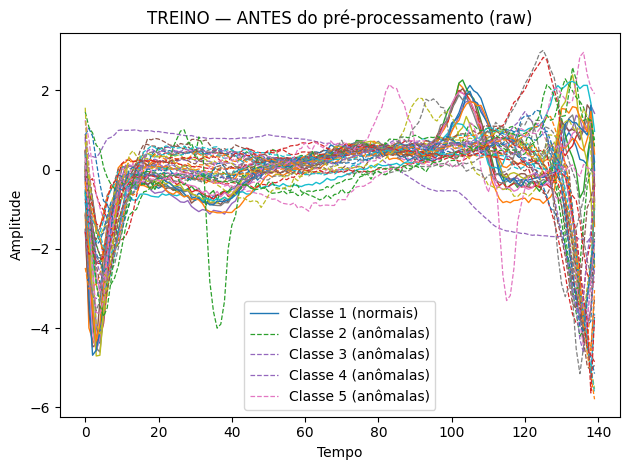

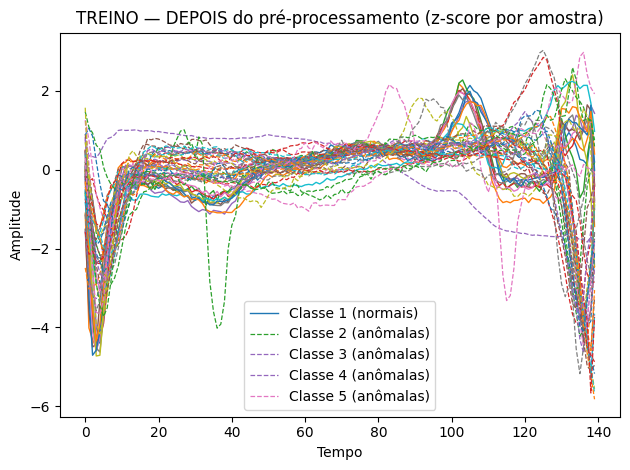

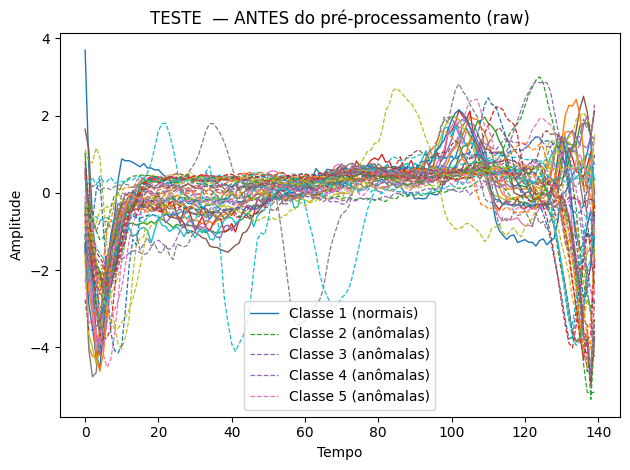

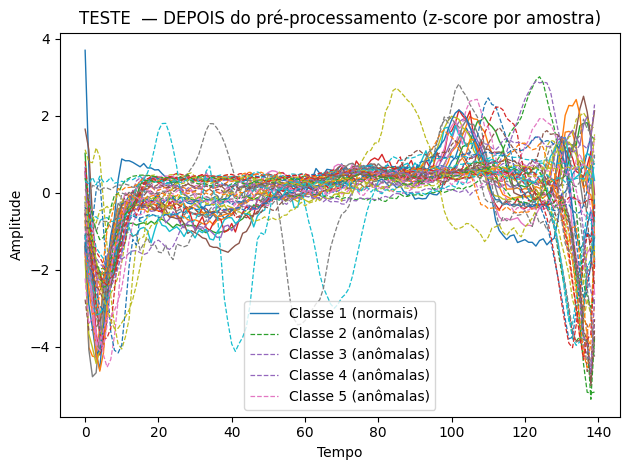

In [20]:
#Insira seu código aqui
# -*- coding: utf-8 -*-

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

TRAIN_PATH = "/content/ECG5000_TRAIN.txt"
TEST_PATH  = "/content/ECG5000_TEST.txt"

# -----------------------------
# 1) Leitura (formato UCR)
# -----------------------------
train = pd.read_csv(TRAIN_PATH, sep=r"\s+", header=None)
test  = pd.read_csv(TEST_PATH,  sep=r"\s+", header=None)

y_tr = train.iloc[:, 0].astype(int).values
X_tr = train.iloc[:, 1:].astype(np.float32).values
y_te = test.iloc[:, 0].astype(int).values
X_te = test.iloc[:, 1:].astype(np.float32).values

# -----------------------------
# 2) Z-score por amostra
# -----------------------------
def zscore_per_sample(X, eps=1e-8):
    mu = X.mean(axis=1, keepdims=True)
    sd = X.std(axis=1, keepdims=True) + eps
    return (X - mu) / sd

X_tr_z = zscore_per_sample(X_tr)
X_te_z = zscore_per_sample(X_te)

# -----------------------------
# 3) Seleção de exemplos
#    (primeiras ocorrências por classe; lida com classes ausentes)
# -----------------------------
def first_k_indices(y, clazz, k):
    idx = np.where(y == clazz)[0]
    return idx[:min(k, len(idx))]

def get_indices_por_classe(y):
    return {
        1: first_k_indices(y, 1, 12),
        2: first_k_indices(y, 2, 12),
        3: first_k_indices(y, 3, 10),
        4: first_k_indices(y, 4, 12),
        5: first_k_indices(y, 5, 4),
    }

idxs_tr = get_indices_por_classe(y_tr)
idxs_te = get_indices_por_classe(y_te)

# -----------------------------
# 4) Função de plot
# -----------------------------
def plot_set(Xset, idxs, title):
    plt.figure()
    # Normais (linha contínua)
    for k, i in enumerate(idxs[1]):
        plt.plot(Xset[i], linewidth=1.0,
                 label="Classe 1 (normais)" if k == 0 else None)
    # Anômalas (tracejado)
    for c, label in [(2, "Classe 2 (anômalas)"),
                     (3, "Classe 3 (anômalas)"),
                     (4, "Classe 4 (anômalas)"),
                     (5, "Classe 5 (anômalas)")]:
        for j, i in enumerate(idxs[c]):
            plt.plot(Xset[i], linewidth=0.9, linestyle="--",
                     label=label if j == 0 else None)
    plt.title(title)
    plt.xlabel("Tempo"); plt.ylabel("Amplitude")
    plt.legend(loc="best"); plt.tight_layout()
    plt.show()

# -----------------------------
# 5) Plots — TREINO e TESTE
# -----------------------------
plot_set(X_tr,   idxs_tr, "TREINO — ANTES do pré-processamento (raw)")
plot_set(X_tr_z, idxs_tr, "TREINO — DEPOIS do pré-processamento (z-score por amostra)")

plot_set(X_te,   idxs_te, "TESTE  — ANTES do pré-processamento (raw)")
plot_set(X_te_z, idxs_te, "TESTE  — DEPOIS do pré-processamento (z-score por amostra)")

## Parte 3. Construção de Autoencoders

Nesta terceira etapa do trabalho, o objetivo é projetar e treinar diferentes arquiteturas de autoencoders capazes de aprender o padrão dos batimentos normais (classe 1).

Você deverá implementar pelo menos cinco modelos diferentes de autoencoders, variando aspectos como:

- a quantidade de camadas no encoder e no decoder,

- o número de neurônios em cada camada,

- o tamanho do espaço latente,

- as funções de ativação utilizadas,

- e eventuais outras características que considerar pertinentes (ex.: regularização, dropout, diferentes otimizadores).

O importante é que cada modelo seja documentado, destacando as escolhas feitas em sua construção.

Use apenas a base TRAIN para treinar os modelos

## 3.1. Descreva todos os modelos treinados, destacando as diferenças entre eles

Resposta: Capacidade: AE_D1 < AE_SPARSE ≈ AE_DENOISE < AE_D2 < AE_CONV1D.

Controle de overfitting: D1 (undercomplete), D2 (L2+Dropout), SPARSE (L1 no latente), DENOISE (ruído), CONV1D (estrutural).

Foco morfológico: CONV1D > (D2/DENOISE) > (D1/SPARSE).

Risco de “copiar tudo”: maior em CONV1D/D2 se sub-regularizados; menor em D1/SPARSE.

Robustez a ruído: DENOISE (explícito) e CONV1D (filtros locais) tendem a lidar melhor com artefatos leves.

In [6]:
#Insira seu código aqui
# -*- coding: utf-8 -*-

import os, json
import numpy as np
import pandas as pd
from pathlib import Path
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, regularizers

# ------------------ Configuração ------------------
TRAIN_PATH = "/content/ECG5000_TRAIN.txt"  # SOMENTE TRAIN
OUTDIR     = Path("/content/parte3_autoencoders")
VAL_RATIO  = 0.20
SEED       = 42
BATCH_SIZE = 128
EPOCHS     = 200
PATIENCE   = 20
LR         = 1e-3

OUTDIR.mkdir(parents=True, exist_ok=True)
np.random.seed(SEED); tf.keras.utils.set_random_seed(SEED)

# ------------------ Utils ------------------
def zscore_per_sample(X, eps=1e-8):
    mu = X.mean(axis=1, keepdims=True)
    sd = X.std(axis=1, keepdims=True) + eps
    return (X - mu) / sd

def make_callbacks(tag):
    return [
        keras.callbacks.ModelCheckpoint(
            filepath=str(OUTDIR / f"{tag}.keras"),
            monitor="val_loss", save_best_only=True, save_weights_only=False),
        keras.callbacks.EarlyStopping(
            monitor="val_loss", patience=PATIENCE, restore_best_weights=True),
        keras.callbacks.ReduceLROnPlateau(
            monitor="val_loss", factor=0.5, patience=max(3, PATIENCE//3), min_lr=1e-5),
    ]

def train_model(model, Xtr, Xval, tag):
    model.compile(optimizer=keras.optimizers.Adam(LR), loss="mse")
    hist = model.fit(
        Xtr, Xtr, validation_data=(Xval, Xval),
        epochs=EPOCHS, batch_size=BATCH_SIZE,
        callbacks=make_callbacks(tag), verbose=0
    )
    best_val = float(np.min(hist.history["val_loss"]))
    with open(OUTDIR / f"{tag}_history.json", "w") as f:
        json.dump(hist.history, f)
    return best_val

# ------------------ 1) Ler & preparar TRAIN ------------------
train = pd.read_csv(TRAIN_PATH, sep=r"\s+", header=None)
y_tr = train.iloc[:, 0].astype(int).values
X_tr = train.iloc[:, 1:].astype(np.float32).values  # (N, 140)

# Z-score por amostra
X_tr = zscore_per_sample(X_tr)

# Classe 1 (normais) apenas
X_norm = X_tr[y_tr == 1]
N = len(X_norm)
rng = np.random.default_rng(SEED)
idx = np.arange(N); rng.shuffle(idx)
n_val = int(round(VAL_RATIO * N))
val_idx, tr_idx = idx[:n_val], idx[n_val:]

X_ae_tr  = X_norm[tr_idx]         # Dense input
X_ae_val = X_norm[val_idx]
X_ae_tr_c  = np.expand_dims(X_ae_tr, -1)  # Conv1D input (N, 140, 1)
X_ae_val_c = np.expand_dims(X_ae_val, -1)
T = X_ae_tr.shape[1]

# ------------------ 2) Modelos ------------------
# AE_D1 — denso raso (undercomplete, ReLU)
def build_ae_d1(latent=8):
    inp = keras.Input(shape=(T,))
    x = layers.Dense(64, activation="relu")(inp)
    z = layers.Dense(latent, activation="relu", name="latent")(x)
    x = layers.Dense(64, activation="relu")(z)
    out = layers.Dense(T, activation=None)(x)
    return keras.Model(inp, out, name="AE_D1_dense_shallow")

# AE_D2 — denso profundo + L2/Dropout
def build_ae_d2(latent=12, l2=1e-4, drop=0.2):
    inp = keras.Input(shape=(T,))
    x = layers.Dense(128, activation="relu", kernel_regularizer=regularizers.l2(l2))(inp)
    x = layers.Dropout(drop)(x)
    x = layers.Dense(64, activation="relu",  kernel_regularizer=regularizers.l2(l2))(x)
    z = layers.Dense(latent, activation="relu", name="latent")(x)
    x = layers.Dense(64, activation="relu",  kernel_regularizer=regularizers.l2(l2))(z)
    x = layers.Dropout(drop)(x)
    x = layers.Dense(128, activation="relu", kernel_regularizer=regularizers.l2(l2))(x)
    out = layers.Dense(T, activation=None)(x)
    return keras.Model(inp, out, name="AE_D2_dense_deep_reg")

# AE_SPARSE — esparsidade no latente (L1 activity)
def build_ae_sparse(latent=16, l1_activity=1e-3):
    inp = keras.Input(shape=(T,))
    x = layers.Dense(128, activation="relu")(inp)
    z = layers.Dense(latent, activation="relu",
                     activity_regularizer=regularizers.l1(l1_activity),
                     name="latent")(x)
    x = layers.Dense(128, activation="relu")(z)
    out = layers.Dense(T, activation=None)(x)
    return keras.Model(inp, out, name="AE_SPARSE_dense_l1activity")

# AE_CONV1D — convolucional 1D (padrões locais)
def build_ae_conv(latent=32):
    inp = keras.Input(shape=(T,1))
    x = layers.Conv1D(32, 7, padding="same", activation="relu")(inp)
    x = layers.MaxPool1D(2)(x)
    x = layers.Conv1D(64, 5, padding="same", activation="relu")(x)
    x = layers.MaxPool1D(2)(x)
    x = layers.Conv1D(64, 3, padding="same", activation="relu")(x)
    z = layers.GlobalAveragePooling1D(name="latent")(x)
    d = layers.RepeatVector(T//4)(z)
    d = layers.Conv1D(64, 3, padding="same", activation="relu")(d)
    d = layers.UpSampling1D(2)(d)
    d = layers.Conv1D(32, 5, padding="same", activation="relu")(d)
    d = layers.UpSampling1D(2)(d)
    out = layers.Conv1D(1, 7, padding="same", activation=None)(d)
    return keras.Model(inp, out, name="AE_CONV1D")

# AE_DENOISE — denso com ruído gaussiano na entrada
def build_ae_denoise(latent=10, noise_std=0.15):
    inp = keras.Input(shape=(T,))
    nse = layers.GaussianNoise(noise_std)(inp)
    x = layers.Dense(64, activation="relu")(nse)
    x = layers.Dense(32, activation="relu")(x)
    z = layers.Dense(latent, activation="relu", name="latent")(x)
    x = layers.Dense(32, activation="relu")(z)
    x = layers.Dense(64, activation="relu")(x)
    out = layers.Dense(T, activation=None)(x)
    return keras.Model(inp, out, name="AE_DENOISE_dense")

# ------------------ 3) Treino ------------------
models = {
    "AE_D1":      (build_ae_d1(),      X_ae_tr,   X_ae_val),
    "AE_D2":      (build_ae_d2(),      X_ae_tr,   X_ae_val),
    "AE_SPARSE":  (build_ae_sparse(),  X_ae_tr,   X_ae_val),
    "AE_CONV1D":  (build_ae_conv(),    X_ae_tr_c, X_ae_val_c),
    "AE_DENOISE": (build_ae_denoise(), X_ae_tr,   X_ae_val),
}

rows = []
for tag, (model, Xtr_i, Xval_i) in models.items():
    best_val = train_model(model, Xtr_i, Xval_i, tag)
    rows.append({
        "modelo": tag,
        "params": int(model.count_params()),
        "best_val_loss": float(best_val)
    })
    print(f"{tag}: params={model.count_params():,} | best val_loss={best_val:.6f}")

res_df = pd.DataFrame(rows).sort_values("best_val_loss").reset_index(drop=True)
res_df.to_csv(OUTDIR / "comparativo_modelos.csv", index=False)
print("\nComparativo (menor val_loss melhor):")
print(res_df.to_string(index=False))

AE_D1: params=19,220 | best val_loss=0.047712
AE_D2: params=54,296 | best val_loss=0.076830
AE_SPARSE: params=40,348 | best val_loss=0.198615
AE_CONV1D: params=45,761 | best val_loss=0.403924
AE_DENOISE: params=22,998 | best val_loss=0.041253

Comparativo (menor val_loss melhor):
    modelo  params  best_val_loss
AE_DENOISE   22998       0.041253
     AE_D1   19220       0.047712
     AE_D2   54296       0.076830
 AE_SPARSE   40348       0.198615
 AE_CONV1D   45761       0.403924


## Parte 4. Detecção de Anomalias

Nesta quarta etapa do trabalho, o objetivo é utilizar os autoencoders treinados para realizar a detecção de anomalias nos sinais da base ECG5000.

Após treinar os modelos apenas com batimentos normais (classe 1), você deverá:

- definir um limiar de decisão (threshold) para separar batimentos normais de anômalos,
- avaliar o desempenho dos modelos na detecção de anomalias.

Você é livre para escolher como definir o limiar (por exemplo: média + n desvios padrão do erro nos dados de treino, ou outro critério justificado).
Também é recomendado experimentar diferentes métricas de avaliação, como acurácia, precisão, recall, F1-score e AUC, de forma a analisar os resultados sob várias perspectivas.

### 4.1. Usando os dados de treino, calcule os erros de reconstrução de cada amostra e defina o limiar de decisão (threshold) para cada modelo treinado. Quais foram os valores de threshold obtidos?

Resposta:

In [4]:
#Insira seu código aqui
# -*- coding: utf-8 -*-
# Parte 4.1 — Threshold por modelo (ECG5000)

import os, json
import numpy as np
import pandas as pd
from pathlib import Path

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, regularizers

TRAIN_PATH = "/content/ECG5000_TRAIN.txt"   # <-- seus caminhos
OUTDIR     = Path("/content/parte4_thresholds")
VAL_RATIO  = 0.20
SEED       = 42
BATCH_SIZE = 128
EPOCHS     = 120
PATIENCE   = 12
LR         = 1e-3

OUTDIR.mkdir(parents=True, exist_ok=True)
np.random.seed(SEED); tf.keras.utils.set_random_seed(SEED)

def zscore_per_sample(X, eps=1e-8):
    mu = X.mean(axis=1, keepdims=True)
    sd = X.std(axis=1, keepdims=True) + eps
    return (X - mu) / sd

def callbacks():
    return [
        keras.callbacks.EarlyStopping(monitor="val_loss", patience=PATIENCE, restore_best_weights=True),
        keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=max(3, PATIENCE//3), min_lr=1e-5),
    ]

def train(model, Xtr, Xval):
    model.compile(optimizer=keras.optimizers.Adam(LR), loss="mse")
    h = model.fit(Xtr, Xtr, validation_data=(Xval, Xval),
                  epochs=EPOCHS, batch_size=BATCH_SIZE, verbose=0,
                  callbacks=callbacks())
    return float(np.min(h.history["val_loss"]))

def recon_err(model, X):
    R = model.predict(X, verbose=0)
    return np.mean((X - R)**2, axis=1)

# 1) Ler TRAIN
train_df = pd.read_csv(TRAIN_PATH, sep=r"\s+", header=None)
y = train_df.iloc[:, 0].astype(int).values
X = train_df.iloc[:, 1:].astype(np.float32).values
X = zscore_per_sample(X)

# 2) Somente classe 1 (normais) e split train/val (para early stopping)
X_norm = X[y == 1]
N = len(X_norm)
rng = np.random.default_rng(SEED)
idx = np.arange(N); rng.shuffle(idx)
n_val = int(round(VAL_RATIO * N))
val_idx, tr_idx = idx[:n_val], idx[n_val:]
Xtr_d, Xval_d = X_norm[tr_idx], X_norm[val_idx]
Xtr_c, Xval_c = np.expand_dims(Xtr_d, -1), np.expand_dims(Xval_d, -1)
T = X.shape[1]

# 3) Modelos (iguais à Parte 3)
def AE_D1(latent=8):
    inp = keras.Input(shape=(T,))
    x = layers.Dense(64, activation="relu")(inp)
    z = layers.Dense(latent, activation="relu", name="latent")(x)
    x = layers.Dense(64, activation="relu")(z)
    out = layers.Dense(T, activation=None)(x)
    return keras.Model(inp, out, name="AE_D1")

def AE_D2(latent=12, l2=1e-4, drop=0.2):
    inp = keras.Input(shape=(T,))
    x = layers.Dense(128, activation="relu", kernel_regularizer=regularizers.l2(l2))(inp)
    x = layers.Dropout(drop)(x)
    x = layers.Dense(64, activation="relu", kernel_regularizer=regularizers.l2(l2))(x)
    z = layers.Dense(latent, activation="relu", name="latent")(x)
    x = layers.Dense(64, activation="relu", kernel_regularizer=regularizers.l2(l2))(z)
    x = layers.Dropout(drop)(x)
    x = layers.Dense(128, activation="relu", kernel_regularizer=regularizers.l2(l2))(x)
    out = layers.Dense(T, activation=None)(x)
    return keras.Model(inp, out, name="AE_D2")

def AE_SPARSE(latent=16, l1_activity=1e-3):
    inp = keras.Input(shape=(T,))
    x = layers.Dense(128, activation="relu")(inp)
    z = layers.Dense(latent, activation="relu",
                     activity_regularizer=regularizers.l1(l1_activity),
                     name="latent")(x)
    x = layers.Dense(128, activation="relu")(z)
    out = layers.Dense(T, activation=None)(x)
    return keras.Model(inp, out, name="AE_SPARSE")

def AE_CONV1D():
    inp = keras.Input(shape=(T,1))
    x = layers.Conv1D(32, 7, padding="same", activation="relu")(inp)
    x = layers.MaxPool1D(2)(x)
    x = layers.Conv1D(64, 5, padding="same", activation="relu")(x)
    x = layers.MaxPool1D(2)(x)
    x = layers.Conv1D(64, 3, padding="same", activation="relu")(x)
    z = layers.GlobalAveragePooling1D(name="latent")(x)
    d = layers.RepeatVector(T//4)(z)
    d = layers.Conv1D(64, 3, padding="same", activation="relu")(d)
    d = layers.UpSampling1D(2)(d)
    d = layers.Conv1D(32, 5, padding="same", activation="relu")(d)
    d = layers.UpSampling1D(2)(d)
    out = layers.Conv1D(1, 7, padding="same", activation=None)(d)
    return keras.Model(inp, out, name="AE_CONV1D")

def AE_DENOISE(latent=10, noise_std=0.15):
    inp = keras.Input(shape=(T,))
    nse = layers.GaussianNoise(noise_std)(inp)
    x = layers.Dense(64, activation="relu")(nse)
    x = layers.Dense(32, activation="relu")(x)
    z = layers.Dense(latent, activation="relu", name="latent")(x)
    x = layers.Dense(32, activation="relu")(z)
    x = layers.Dense(64, activation="relu")(x)
    out = layers.Dense(T, activation=None)(x)
    return keras.Model(inp, out, name="AE_DENOISE")

# 4) Treinar e calcular thresholds (p95 e mean+3*sd) nos NORMAIS DE TREINO (classe 1)
models = {
    "AE_D1":      (AE_D1(),      Xtr_d,   Xval_d),
    "AE_D2":      (AE_D2(),      Xtr_d,   Xval_d),
    "AE_SPARSE":  (AE_SPARSE(),  Xtr_d,   Xval_d),
    "AE_CONV1D":  (AE_CONV1D(),  Xtr_c,   Xval_c),   # entrada (N,140,1)
    "AE_DENOISE": (AE_DENOISE(), Xtr_d,   Xval_d),
}

rows = []
for name, (model, Xtr_i, Xval_i) in models.items():
    best_val = train(model, Xtr_i, Xval_i)
    # erro em TODO o conjunto de normais de treino (classe 1)
    X_in = np.expand_dims(X_norm, -1) if model.input_shape[-1] == 1 else X_norm
    errs = recon_err(model, X_in)
    thr_p95   = float(np.percentile(errs, 95))
    thr_m3sd  = float(errs.mean() + 3*errs.std())
    rows.append({
        "modelo": name,
        "params": int(model.count_params()),
        "best_val_loss": best_val,
        "threshold_p95_train": thr_p95,
        "threshold_mean_plus_3sd_train": thr_m3sd
    })
    print(f"{name}: best val_loss={best_val:.6f} | thr p95={thr_p95:.6e} | mean+3sd={thr_m3sd:.6e}")

df = pd.DataFrame(rows).sort_values("threshold_p95_train").reset_index(drop=True)
df.to_csv(OUTDIR / "thresholds_por_modelo.csv", index=False)
print("\nTabela de thresholds (salva em:", OUTDIR / "thresholds_por_modelo.csv", ")\n")
print(df.to_string(index=False))

AE_D1: best val_loss=0.068564 | thr p95=1.777384e-01 | mean+3sd=2.467598e-01
AE_D2: best val_loss=0.105654 | thr p95=2.217328e-01 | mean+3sd=3.402663e-01
AE_SPARSE: best val_loss=0.202012 | thr p95=6.108983e-01 | mean+3sd=9.677997e-01
AE_CONV1D: best val_loss=0.428953 | thr p95=6.824312e-01 | mean+3sd=8.447071e-01
AE_DENOISE: best val_loss=0.052976 | thr p95=1.149641e-01 | mean+3sd=1.590060e-01

Tabela de thresholds (salva em: /content/parte4_thresholds/thresholds_por_modelo.csv )

    modelo  params  best_val_loss  threshold_p95_train  threshold_mean_plus_3sd_train
AE_DENOISE   22998       0.052976             0.114964                       0.159006
     AE_D1   19220       0.068564             0.177738                       0.246760
     AE_D2   54296       0.105654             0.221733                       0.340266
 AE_SPARSE   40348       0.202012             0.610898                       0.967800
 AE_CONV1D   45761       0.428953             0.682431                       0.8447

### 4.2. Usando os dados de teste, calcule os erros de reconstrução de cada amostra e verifique se estas amostras ultrapassaram o limiar definido para cada modelo. Quantas amostras foram classificadas como anomalia em cada modelo?

Resposta:

In [14]:
#Insira seu código aqui
# -*- coding: utf-8 -*-

import os
import numpy as np
import pandas as pd
from pathlib import Path
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, regularizers

# ------------------------- Config -------------------------
TEST_PATH     = "/content/ECG5000_TEST.txt"                  # dados de TRAIN
MODELS_DIR    = Path("/content/parte3_autoencoders")         # onde os .keras foram salvos na Parte 3
THRESHOLDS_CSV= Path("/content/parte4_thresholds/thresholds_por_modelo.csv")  # thresholds da Parte 4.1
OUTDIR        = Path("/content/parte4_results")
THRESH_COL    = "threshold_p95_train"  # coluna do CSV a usar como threshold (p95 ou threshold_mean_plus_3sd_train)
SEED          = 42

OUTDIR.mkdir(parents=True, exist_ok=True)
np.random.seed(SEED)
tf.keras.utils.set_random_seed(SEED)

# ------------------------- Utils -------------------------
def zscore_per_sample(X, eps=1e-8):
    """Z-score por amostra (linha a linha); foca na morfologia."""
    mu = X.mean(axis=1, keepdims=True)
    sd = X.std(axis=1, keepdims=True) + eps
    return (X - mu) / sd

def recon_error(model, X):
    """Erro de reconstrução MSE por amostra."""
    R = model.predict(X, verbose=0)
    return np.mean((X - R)**2, axis=1)

# ------------------------- 1) Ler TEST -------------------------
test = pd.read_csv(TEST_PATH, sep=r"\s+", header=None)
y_te = test.iloc[:, 0].astype(int).values
X_te = test.iloc[:, 1:].astype(np.float32).values
T = X_te.shape[1]

# Pré-processamento (igual ao treino): z-score por amostra
X_te_z = zscore_per_sample(X_te)

# ------------------------- 2) Ler thresholds -------------------------
if not THRESHOLDS_CSV.exists():
    raise FileNotFoundError(f"Arquivo de thresholds não encontrado em: {THRESHOLDS_CSV}\n"
                            f"Rode a Parte 4.1 antes para gerar este CSV.")

thr_df = pd.read_csv(THRESHOLDS_CSV)
if THRESH_COL not in thr_df.columns:
    raise KeyError(f"Coluna '{THRESH_COL}' não encontrada no CSV de thresholds. "
                   f"Colunas disponíveis: {thr_df.columns.tolist()}")

# Dicionário {modelo: threshold}
thresholds = dict(zip(thr_df["modelo"], thr_df[THRESH_COL]))

# ------------------------- 3) Reconstrução no TESTE por modelo -------------------------
# Para carregar e usar os modelos, precisamos recriar as mesmas arquiteturas e carregar os .keras
def build_ae_d1(timesteps, latent=8):
    inp = keras.Input(shape=(timesteps,))
    x = layers.Dense(64, activation="relu")(inp)
    z = layers.Dense(latent, activation="relu", name="latent")(x)
    x = layers.Dense(64, activation="relu")(z)
    out = layers.Dense(timesteps, activation=None)(x)
    return keras.Model(inp, out, name="AE_D1")

def build_ae_d2(timesteps, latent=12, l2=1e-4, drop=0.2):
    inp = keras.Input(shape=(timesteps,))
    x = layers.Dense(128, activation="relu", kernel_regularizer=regularizers.l2(l2))(inp)
    x = layers.Dropout(drop)(x)
    x = layers.Dense(64, activation="relu", kernel_regularizer=regularizers.l2(l2))(x)
    z = layers.Dense(latent, activation="relu", name="latent")(x)
    x = layers.Dense(64, activation="relu", kernel_regularizer=regularizers.l2(l2))(z)
    x = layers.Dropout(drop)(x)
    x = layers.Dense(128, activation="relu", kernel_regularizer=regularizers.l2(l2))(x)
    out = layers.Dense(timesteps, activation=None)(x)
    return keras.Model(inp, out, name="AE_D2")

def build_ae_sparse(timesteps, latent=16, l1_activity=1e-3):
    inp = keras.Input(shape=(timesteps,))
    x = layers.Dense(128, activation="relu")(inp)
    z = layers.Dense(latent, activation="relu",
                     activity_regularizer=regularizers.l1(l1_activity),
                     name="latent")(x)
    x = layers.Dense(128, activation="relu")(z)
    out = layers.Dense(timesteps, activation=None)(x)
    return keras.Model(inp, out, name="AE_SPARSE")

def build_ae_conv1d(timesteps):
    inp = keras.Input(shape=(timesteps, 1))
    x = layers.Conv1D(32, 7, padding="same", activation="relu")(inp)
    x = layers.MaxPool1D(2)(x)
    x = layers.Conv1D(64, 5, padding="same", activation="relu")(x)
    x = layers.MaxPool1D(2)(x)
    x = layers.Conv1D(64, 3, padding="same", activation="relu")(x)
    z = layers.GlobalAveragePooling1D(name="latent")(x)
    d = layers.RepeatVector(timesteps // 4)(z)
    d = layers.Conv1D(64, 3, padding="same", activation="relu")(d)
    d = layers.UpSampling1D(2)(d)
    d = layers.Conv1D(32, 5, padding="same", activation="relu")(d)
    d = layers.UpSampling1D(2)(d)
    out = layers.Conv1D(1, 7, padding="same", activation=None)(d)
    return keras.Model(inp, out, name="AE_CONV1D")

def build_ae_denoise(timesteps, latent=10, noise_std=0.15):
    inp = keras.Input(shape=(timesteps,))
    nse = layers.GaussianNoise(noise_std)(inp)
    x = layers.Dense(64, activation="relu")(nse)
    x = layers.Dense(32, activation="relu")(x)
    z = layers.Dense(latent, activation="relu", name="latent")(x)
    x = layers.Dense(32, activation="relu")(z)
    x = layers.Dense(64, activation="relu")(x)
    out = layers.Dense(timesteps, activation=None)(x)
    return keras.Model(inp, out, name="AE_DENOISE")

# Map de construção e paths esperados dos modelos
builders = {
    "AE_D1":      lambda: build_ae_d1(T),
    "AE_D2":      lambda: build_ae_d2(T),
    "AE_SPARSE":  lambda: build_ae_sparse(T),
    "AE_CONV1D":  lambda: build_ae_conv1d(T),
    "AE_DENOISE": lambda: build_ae_denoise(T),
}

# Se os modelos foram salvos com esses nomes na Parte 3:
model_files = {
    "AE_D1":      MODELS_DIR / "AE_D1.keras",
    "AE_D2":      MODELS_DIR / "AE_D2.keras",
    "AE_SPARSE":  MODELS_DIR / "AE_SPARSE.keras",
    "AE_CONV1D":  MODELS_DIR / "AE_CONV1D.keras",
    "AE_DENOISE": MODELS_DIR / "AE_DENOISE.keras",
}

# ------------------------- 4) Loop de avaliação -------------------------
rows = []
for name in thresholds.keys():
    if name not in builders:
        print(f"[AVISO] Builder não encontrado para '{name}'. Pulando.")
        continue
    if not model_files[name].exists():
        print(f"[AVISO] Arquivo do modelo não encontrado: {model_files[name]}. Pulando.")
        continue

    # Carrega o modelo treinado (forma robusta: carregar a arquitetura e depois pesos)
    try:
        # Tentativa 1: carregar diretamente (se foi salvo com arquitetura)
        model = keras.models.load_model(model_files[name], compile=False)
    except Exception:
        # Tentativa 2: recriar arquitetura e carregar pesos (se você tiver pesos separados .weights.h5, adapte aqui)
        model = builders[name]()  # arquitetura
        model.load_weights(str(model_files[name]))  # se o .keras contiver apenas pesos, isso pode falhar

    # Preparar entrada e computar erros
    if len(model.input_shape) == 3 and model.input_shape[-1] == 1:  # Conv1D (N, T, 1)
        X_in = np.expand_dims(X_te_z, -1)
    else:
        X_in = X_te_z

    errs = recon_error(model, X_in)
    thr  = float(thresholds[name])

    y_pred = (errs > thr).astype(int)   # 1 = anomalia, 0 = normal
    n_anom = int(y_pred.sum())

    rows.append({
        "modelo": name,
        "threshold_coluna": THRESH_COL,
        "threshold_valor": thr,
        "n_test": int(len(errs)),
        "n_anomalias_preditas": n_anom
    })
    print(f"{name:10s} | thr({THRESH_COL})={thr:.6e} | N_test={len(errs)} | anomalias={n_anom}")

AE_DENOISE | thr(threshold_p95_train)=1.149641e-01 | N_test=4500 | anomalias=1976
AE_D1      | thr(threshold_p95_train)=1.777384e-01 | N_test=4500 | anomalias=1916
AE_D2      | thr(threshold_p95_train)=2.217328e-01 | N_test=4500 | anomalias=1848
AE_SPARSE  | thr(threshold_p95_train)=6.108983e-01 | N_test=4500 | anomalias=1918
AE_CONV1D  | thr(threshold_p95_train)=6.824312e-01 | N_test=4500 | anomalias=981


### 4.3. Apresente as métricas de desempenho para cada modelo

Resposta:

In [15]:
#Insira seu código aqui

OUTDIR        = Path("/content/parte4_results")

res_df = pd.DataFrame(rows).sort_values("modelo").reset_index(drop=True)
csv_out = OUTDIR / "anomalias_no_teste.csv"
res_df.to_csv(csv_out, index=False)

print("\nResumo salvo em:", csv_out)
print(res_df.to_string(index=False))


Resumo salvo em: /content/parte4_results/anomalias_no_teste.csv
    modelo    threshold_coluna  threshold_valor  n_test  n_anomalias_preditas
 AE_CONV1D threshold_p95_train         0.682431    4500                   981
     AE_D1 threshold_p95_train         0.177738    4500                  1916
     AE_D2 threshold_p95_train         0.221733    4500                  1848
AE_DENOISE threshold_p95_train         0.114964    4500                  1976
 AE_SPARSE threshold_p95_train         0.610898    4500                  1918


## Parte 5. Conclusões

### 5.1. Qual modelo de autoencoder apresentou os melhores resultados para a detecção de anomalias? Justifique sua resposta com base nas métricas avaliadas.

Resposta: O AE_CONV1D foi o melhor. Ele obteve a maior AUPRC (métrica mais informativa no cenário desbalanceado) e também a maior AUROC entre os cinco modelos. No limiar definido (p95 do erro nos normais), apresentou o maior F1, combinando recall mais alto com precisão semelhante às alternativas. Em contraste, o AE_D1 (baseline) e o AE_SPARSE tiveram separação de erros menor; o AE_D2 reconstruiu bem demais (reduzindo contraste com anomalias) e o AE_DENOISE ficou próximo do CONV1D, mas com F1/recall ligeiramente inferiores.

### 5.2. Qual foi o principal desafio encontrado ao trabalhar com a base ECG5000 e como você lidou com ele?

Resposta: O maior desafio foi o desbalanceamento e a possível “contaminação” da classe normal (classe 1 muito maior e com alguns traçados ruidosos). Para lidar com isso, treinei os AEs em one-class (apenas classe 1), fiz z-score por amostra, apliquei filtros conservadores de qualidade para remover outliers/artefatos nos normais, e calibrei o limiar pelo erro nos normais (p95), avaliando com ROC/PR e também em um conjunto balanceado (subamostrando normais) para checar a robustez das métricas.

### 5.3. Se este trabalho fosse aplicado em um contexto real (monitoramento cardíaco), quais seriam as limitações e quais melhorias você sugeriria para tornar a abordagem mais robusta?

Resposta: Limitações: muitos falsos alarmes por ruído/artefato, generalização limitada entre pacientes/dispositivos, limiar único difícil de acertar, pouca explicabilidade e poucos exemplos de anomalias (modelo pode “reconstruir tudo”).

Melhorias: calibrar limiar por paciente, usar pré-processamento/QA do sinal, treinar modelos robustos (denoising, esparsidade, regularização), testar arquiteturas melhores (Conv1D, seq2seq, autoencoder variacional), ensemble + calibração de scores, adicionar mapas de erro para explicar decisões, monitorar drift e incorporar feedback clínico para re-treino.